Dataset:
    Word_Frequency  Message_Length  Spam
0                2             120     0
1                4             180     0
2                1              90     0
3                3             150     0
4                5             220     1
5                2             130     0
6                6             260     1
7                1              80     0
8                4             170     0
9                7             300     1
10               3             140     0
11               8             320     1
12               2             110     0
13               5             210     1
14               1              95     0
15               6             250     1
16               7             280     1
17               2             125     0
18               3             160     0
19               9             350     1
20               4             190     0
21               8             310     1
22               1             100     0
23     

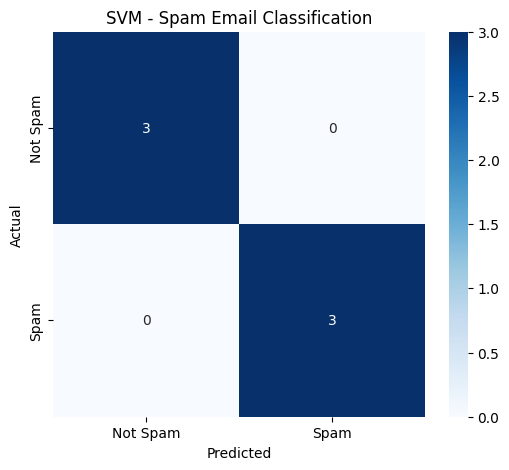


New Email Prediction: SPAM


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# CH.SC.U4CSE24149
# VIGHRANTH SK
# MACHINE LEARNING - ACTIVITY 8
# SUPPORT VECTOR MACHINES (SVM)
# Exercise 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Create the dataset

data = {
    'Word_Frequency': [
        2, 4, 1, 3, 5, 2, 6, 1, 4, 7,
        3, 8, 2, 5, 1, 6, 7, 2, 3, 9,
        4, 8, 1, 6, 5, 2, 7, 3, 9, 4
    ],

    'Message_Length': [
        120, 180, 90, 150, 220, 130, 260, 80, 170, 300,
        140, 320, 110, 210, 95, 250, 280, 125, 160, 350,
        190, 310, 100, 240, 200, 115, 275, 155, 330, 185
    ],

    'Spam': [
        0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
        0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
        0, 1, 0, 1, 1, 0, 1, 0, 1, 0
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# 2. Define the input and output

X = df[['Word_Frequency', 'Message_Length']]
y = df['Spam']

# 3. Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

# 4. Scale the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Create the SVM classifier

model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

# 6. Train the model

model.fit(X_train_scaled, y_train)

# 7. Make predictions

y_pred = model.predict(X_test_scaled)

print("\nPredicted values:")
print(y_pred)

print("\nActual values:")
print(y_test.values)

# 8. Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy in percentage:", accuracy * 100, "%")

# 9. Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# 10. Generate classification report

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Not Spam', 'Spam']
    )
)

# 11. Visualize the confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Spam', 'Spam'],
    yticklabels=['Not Spam', 'Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Spam Email Classification")
plt.show()

# 12. Test a new email

new_email = [[6, 230]]

new_email_scaled = scaler.transform(new_email)

prediction = model.predict(new_email_scaled)

if prediction[0] == 1:
    print("\nNew Email Prediction: SPAM")
else:
    print("\nNew Email Prediction: NOT SPAM")